In [1]:
# Librerias

import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import random
import math
import pandas as pd
import seaborn as sns
from tqdm import tqdm

In [2]:
# Directorios
base_dir = Path("../data/mask/train")
classes = ["Benign", "Malignant"]

# Extraccion de Feautures

## Circularidad

In [3]:
def calcular_circularidad(mask_path, visualizar=False):
   
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"No se pudo leer la imagen: {mask_path}")
        
    # Binarizar
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    
    # Contorno principal
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)
    
    if perimetro == 0:
        return 0.0

    circularidad = (4 * math.pi * area) / (perimetro ** 2)
    circularidad = round(circularidad, 4)

    return circularidad


### Pruebas Circularidad

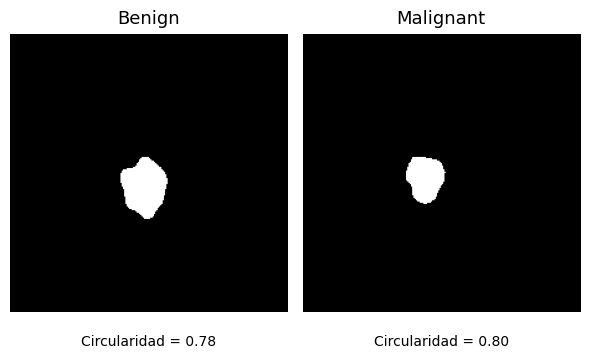

In [4]:
sample_paths = []
for cls in classes:
    paths = list((base_dir / cls).glob("*.png"))
    if paths:
        sample_paths.append((random.choice(paths), cls))


fig, axs = plt.subplots(1, 2, figsize=(6, 4))
fig.patch.set_facecolor("white")

for ax, (path, cls) in zip(axs, sample_paths):
    img = cv2.imread(str(path))
    if img is None:
        print(f"No se pudo leer la imagen: {path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    perimetro = calcular_circularidad(path)

    ax.imshow(img_rgb, cmap="gray")
    ax.set_title(f"{cls}", fontsize=13, color="black", pad=8)
    ax.axis("off")

    # Añadir texto centrado debajo
    ax.text(
        0.5, -0.08, f"Circularidad = {perimetro:.2f}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=10, color="black"
    )

plt.tight_layout()
plt.show()

In [5]:
resultados_circularidad= []

for cls in classes:

    cls_dir = base_dir / cls
    mask_paths = list(cls_dir.glob("*.png"))

    for path in mask_paths:
        circ = calcular_circularidad(path)
        resultados_circularidad.append({
            "nombre_imagen": path.name,
            "clase": cls,
            "circularidad": circ
        })


df_circularidad= pd.DataFrame(resultados_circularidad)
df_circularidad.head()

,nombre_imagen,clase,circularidad
0,3975.png,Benign,0.5955
1,348.png,Benign,0.6002
2,1804.png,Benign,0.7045
3,4968.png,Benign,0.7867
4,1810.png,Benign,0.4625


### BoxPlot

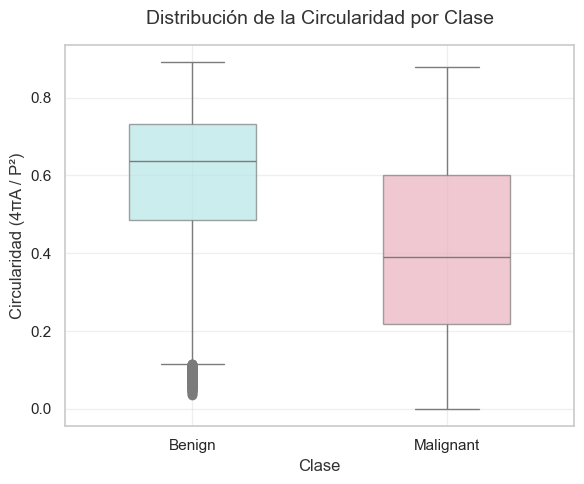

In [6]:
sns.set(style="whitegrid", palette="pastel")

plt.figure(figsize=(6,5))


sns.boxplot(
    data=df_circularidad,
    x="clase",
    y="circularidad",
    hue="clase",         
    dodge=False,
    legend=False,    
    palette={"Benign": "#AEEEEE", "Malignant": "#F4A7B9"},
    width=0.5,
    boxprops=dict(alpha=0.7)
)


plt.title("Distribución de la Circularidad por Clase", fontsize=14, color="#333", pad=15)
plt.xlabel("Clase", fontsize=12, color="#333")
plt.ylabel("Circularidad (4πA / P²)", fontsize=12, color="#333")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resumen Circularidad

In [7]:
stats = df_circularidad.groupby("clase")["circularidad"].agg(["mean"]).reset_index()
stats


,clase,mean
0,Benign,0.585972
1,Malignant,0.410338


##  Perimetro

In [8]:
def calcular_perimetro(mask_path):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return np.nan

    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.nan

    cnt = max(contours, key=cv2.contourArea)
    perimetro = cv2.arcLength(cnt, True)
    return round(perimetro, 2)

### Pruebas Perímetro

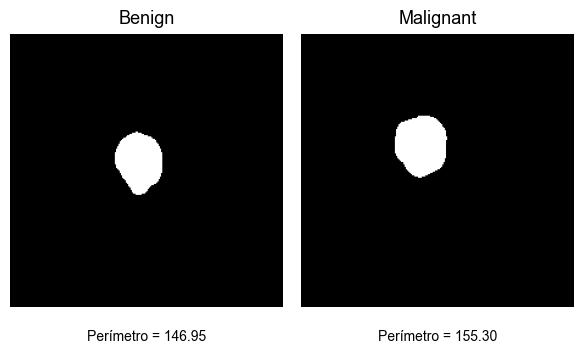

In [9]:
sample_paths = []
for cls in classes:
    paths = list((base_dir / cls).glob("*.png"))
    if paths:
        sample_paths.append((random.choice(paths), cls))


fig, axs = plt.subplots(1, 2, figsize=(6, 4))
fig.patch.set_facecolor("white")

for ax, (path, cls) in zip(axs, sample_paths):
    img = cv2.imread(str(path))
    if img is None:
        print(f"No se pudo leer la imagen: {path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    perimetro = calcular_perimetro(path)

    ax.imshow(img_rgb, cmap="gray")
    ax.set_title(f"{cls}", fontsize=13, color="black", pad=8)
    ax.axis("off")

    # Añadir texto centrado debajo
    ax.text(
        0.5, -0.08, f"Perímetro = {perimetro:.2f}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=10, color="black"
    )

plt.tight_layout()
plt.show()

In [10]:
resultados_per= []

for cls in classes:
    cls_dir = base_dir / cls
    mask_paths = list(cls_dir.glob("*.png"))

    for path in mask_paths:
        peri = calcular_perimetro(path)
        resultados_per.append({
            "nombre_imagen": path.name,
            "clase": cls,
            "perimetro": peri
        })

# --- Crear DataFrame ---
df_perimetro = pd.DataFrame(resultados_per)
df_perimetro

,nombre_imagen,clase,perimetro
0,3975.png,Benign,210.51
1,348.png,Benign,683.80
2,1804.png,Benign,213.48
3,4968.png,Benign,198.61
4,1810.png,Benign,268.75
...,...,...,...
11874,345.png,Malignant,248.17
11875,4971.png,Malignant,1379.56
11876,4965.png,Malignant,564.11
11877,351.png,Malignant,1259.58


### BoxPlot

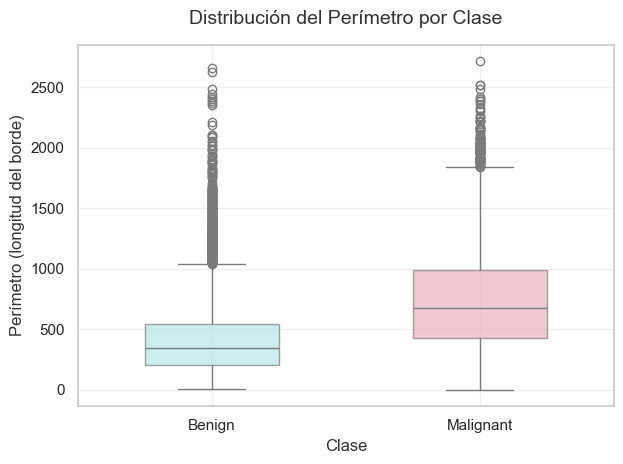

In [11]:
sns.boxplot(
    data=df_perimetro,
    x="clase",
    y="perimetro",
    hue="clase",            
    dodge=False,
    legend=False,
    palette={"Benign": "#AEEEEE", "Malignant": "#F4A7B9"},
    width=0.5,
    boxprops=dict(alpha=0.7)
)


plt.title("Distribución del Perímetro por Clase", fontsize=14, color="#333", pad=15)
plt.xlabel("Clase", fontsize=12, color="#333")
plt.ylabel("Perímetro (longitud del borde)", fontsize=12, color="#333")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Media Perímetro

In [12]:
stats = df_perimetro.groupby("clase")["perimetro"].agg(["mean"]).reset_index()
stats


,clase,mean
0,Benign,429.148499
1,Malignant,742.681889


## Area

In [13]:
def calcular_area(mask_path):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return np.nan

    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.nan

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    return round(area, 2)

### Prueba Area

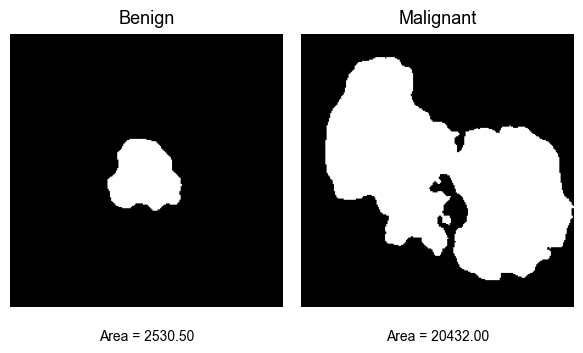

In [14]:
sample_paths = []
for cls in classes:
    paths = list((base_dir / cls).glob("*.png"))
    if paths:
        sample_paths.append((random.choice(paths), cls))


fig, axs = plt.subplots(1, 2, figsize=(6, 4))
fig.patch.set_facecolor("white")

for ax, (path, cls) in zip(axs, sample_paths):
    img = cv2.imread(str(path))
    if img is None:
        print(f"No se pudo leer la imagen: {path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    area = calcular_area(path)

    ax.imshow(img_rgb, cmap="gray")
    ax.set_title(f"{cls}", fontsize=13, color="black", pad=8)
    ax.axis("off")

    # Añadir texto centrado debajo
    ax.text(
        0.5, -0.08, f"Area = {area:.2f}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=10, color="black"
    )

plt.tight_layout()
plt.show()

### Boxplot

In [15]:
resultados_ar= []

for cls in classes:
    cls_dir = base_dir / cls
    mask_paths = list(cls_dir.glob("*.png"))

    for path in mask_paths:
        area = calcular_area(path)
        resultados_ar.append({
            "nombre_imagen": path.name,
            "clase": cls,
            "area": area
        })

# --- Crear DataFrame ---
df_area = pd.DataFrame(resultados_ar)
df_area

,nombre_imagen,clase,area
0,3975.png,Benign,2100.0
1,348.png,Benign,22333.5
2,1804.png,Benign,2555.0
3,4968.png,Benign,2469.5
4,1810.png,Benign,2658.5
...,...,...,...
11874,345.png,Malignant,2445.0
11875,4971.png,Malignant,23195.5
11876,4965.png,Malignant,13233.5
11877,351.png,Malignant,25549.5


### BoxPlot

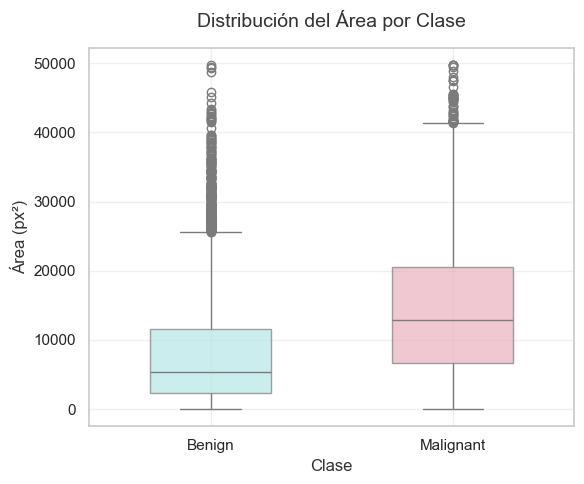

In [16]:
import seaborn as sns

sns.set(style="whitegrid", palette="pastel")

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_area,
    x="clase",
    y="area",
    hue="clase",
    dodge=False,
    legend=False,
    palette={"Benign": "#AEEEEE", "Malignant": "#F4A7B9"},
    width=0.5,
    boxprops=dict(alpha=0.7)
)



plt.title("Distribución del Área por Clase", fontsize=14, color="#333", pad=15)
plt.xlabel("Clase", fontsize=12, color="#333")
plt.ylabel("Área (px²)", fontsize=12, color="#333")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Resumen Area

In [17]:
stats = df_area.groupby("clase")["area"].agg(["mean"]).reset_index()
stats

,clase,mean
0,Benign,8137.767054
1,Malignant,14433.011360


## Solidez

In [18]:
def calcular_solidez(mask_path):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:

        return np.nan
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return np.nan
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    hull = cv2.convexHull(cnt)
    area_hull = cv2.contourArea(hull)
    if area_hull == 0:
        return np.nan
    return round(area / area_hull, 3)

### Prueba Solided

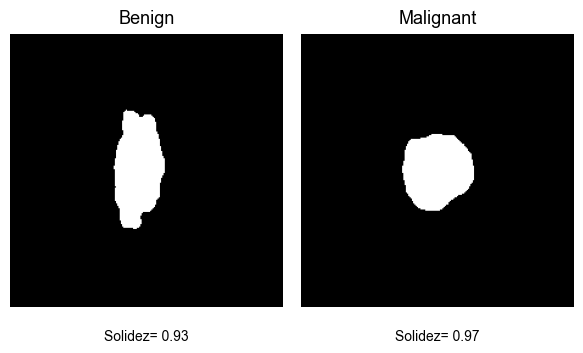

In [19]:
sample_paths = []
for cls in classes:
    paths = list((base_dir / cls).glob("*.png"))
    if paths:
        sample_paths.append((random.choice(paths), cls))


fig, axs = plt.subplots(1, 2, figsize=(6, 4))
fig.patch.set_facecolor("white")

for ax, (path, cls) in zip(axs, sample_paths):
    img = cv2.imread(str(path))
    if img is None:
        print(f"No se pudo leer la imagen: {path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    solided = calcular_solidez(path)

    ax.imshow(img_rgb, cmap="gray")
    ax.set_title(f"{cls}", fontsize=13, color="black", pad=8)
    ax.axis("off")

    # Añadir texto centrado debajo
    ax.text(
        0.5, -0.08, f"Solidez= {solided:.2f}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=10, color="black"
    )

plt.tight_layout()
plt.show()

In [22]:
resultados_sol = []

for cls in classes:
    cls_dir = base_dir / cls
    mask_paths = list(cls_dir.glob("*.png"))

    for path in mask_paths:
        sol = calcular_solidez(path)
        resultados_sol.append({    
            "nombre_imagen": path.name,
            "clase": cls,
            "solidez": sol
        })


df_solidez = pd.DataFrame(resultados_sol)

df_solidez


,nombre_imagen,clase,solidez
0,3975.png,Benign,0.907
1,348.png,Benign,0.907
2,1804.png,Benign,0.922
3,4968.png,Benign,0.955
4,1810.png,Benign,0.861
...,...,...,...
11874,345.png,Malignant,0.842
11875,4971.png,Malignant,0.784
11876,4965.png,Malignant,0.887
11877,351.png,Malignant,0.686


### BoxPlot

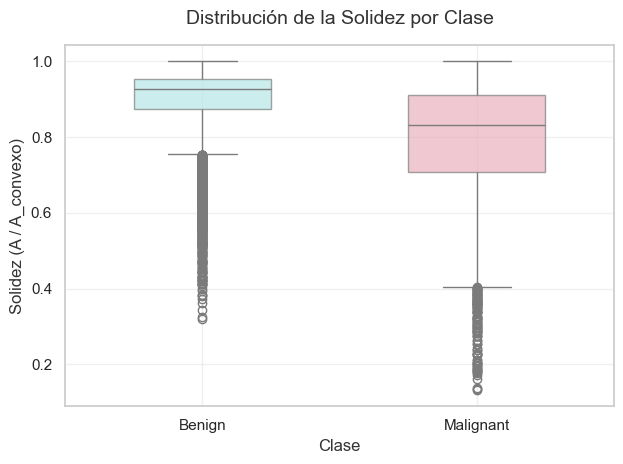

In [23]:
sns.boxplot(
    data=df_solidez,
    x="clase",
    y="solidez",           
    hue="clase",
    dodge=False,
    legend=False,
    palette={"Benign": "#AEEEEE", "Malignant": "#F4A7B9"},
    width=0.5,
    boxprops=dict(alpha=0.7)
)

plt.title("Distribución de la Solidez por Clase", fontsize=14, color="#333", pad=15)
plt.xlabel("Clase", fontsize=12, color="#333")
plt.ylabel("Solidez (A / A_convexo)", fontsize=12, color="#333")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
stats = df_solidez.groupby("clase")["solidez"].agg(["mean"]).reset_index()
stats

,clase,mean
0,Benign,0.890168
1,Malignant,0.795091


## Asimetría

**Graficar:**

In [25]:
def visualizar_resultados(mask_centered, cx, cy, file):
    plt.style.use('dark_background')

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    # === Fila 1: CORTE VERTICAL ===
    axes[0, 0].imshow(mask_centered, cmap='gray')
    axes[0, 0].axvline(x=cx, color='red', linestyle='--', linewidth=1.5, label='Eje vertical')
    axes[0, 0].legend(facecolor='black', loc='lower right', fontsize=8)
    axes[0, 0].set_title(f'{file}\nLesión centrada', color='white')

    # Mitades verticales
    left = mask_centered[:, :cx]
    right = mask_centered[:, cx:]
    right_flipped = np.fliplr(right)
    min_width = min(left.shape[1], right_flipped.shape[1])
    
    axes[0, 1].imshow(left[:, :min_width], cmap='gray')
    axes[0, 1].set_title('Mitad izquierda', color='white')

    axes[0, 2].imshow(right_flipped[:, :min_width], cmap='gray')
    axes[0, 2].set_title('Mitad derecha reflejada', color='white')

    # === Fila 2: CORTE HORIZONTAL ===
    axes[1, 0].imshow(mask_centered, cmap='gray')
    axes[1, 0].axhline(y=cy, color='deepskyblue', linestyle='--', linewidth=1.5, label='Eje horizontal')
    axes[1, 0].legend(facecolor='black', loc='lower right', fontsize=8)
    axes[1, 0].set_title('Lesión centrada', color='white')

    # Mitades horizontales
    top = mask_centered[:cy, :]
    bottom = mask_centered[cy:, :]
    bottom_flipped = np.flipud(bottom)
    min_height = min(top.shape[0], bottom_flipped.shape[0])
    
    axes[1, 1].imshow(top[:min_height, :], cmap='gray')
    axes[1, 1].set_title('Mitad superior', color='white')

    axes[1, 2].imshow(bottom_flipped[:min_height, :], cmap='gray')
    axes[1, 2].set_title('Mitad inferior reflejada', color='white')

    # --- Ajustes estéticos ---
    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.show()




**Calcular:**

In [ ]:
def calcular_simetria(mask_path, visualizar=False):
    # Leer imagen
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return np.nan, np.nan

    # Binarizar (0-1)
    _, mask_bin = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
    if np.sum(mask_bin) == 0:
        return np.nan, np.nan

    # Centrar la máscara
    y, x = np.where(mask_bin > 0)
    y_min, y_max = y.min(), y.max()
    x_min, x_max = x.min(), x.max()
    roi = mask_bin[y_min:y_max+1, x_min:x_max+1]
    h, w = roi.shape
    size = max(h, w)
    canvas = np.zeros((size, size), dtype=np.uint8)
    y_off, x_off = (size - h)//2, (size - w)//2
    canvas[y_off:y_off+h, x_off:x_off+w] = roi
    mask_centered = canvas

    # Calcular centroides
    coords = np.column_stack(np.where(mask_centered > 0))
    cy, cx = np.mean(coords, axis=0).astype(int)
    area_total = np.sum(mask_centered)

    # === VERTICAL ===
    left = mask_centered[:, :cx]
    right = mask_centered[:, cx:
    right_flipped = np.fliplr(right)
    min_width = min(left.shape[1], right_flipped.shape[1])
    xor_v = np.logical_xor(left[:, :min_width], right_flipped[:, :min_width])
    asym_v = np.sum(xor_v) / area_total
    sim_v = 1 - asym_v  # índice de simetría

    # === HORIZONTAL ===
    top = mask_centered[:cy, :]
    bottom = mask_centered[cy:, :]
    bottom_flipped = np.flipud(bottom)
    min_height = min(top.shape[0], bottom_flipped.shape[0])
    xor_h = np.logical_xor(top[:min_height, :], bottom_flipped[:min_height, :])
    asym_h = np.sum(xor_h) / area_total
    sim_h = 1 - asym_h  # índice de simetría

    # === Visualización opcional ===
    if visualizar:
        visualizar_resultados(mask_centered,  cx, cy, mask_path)

    return sim_v, sim_h



### Pruebas Asimetria

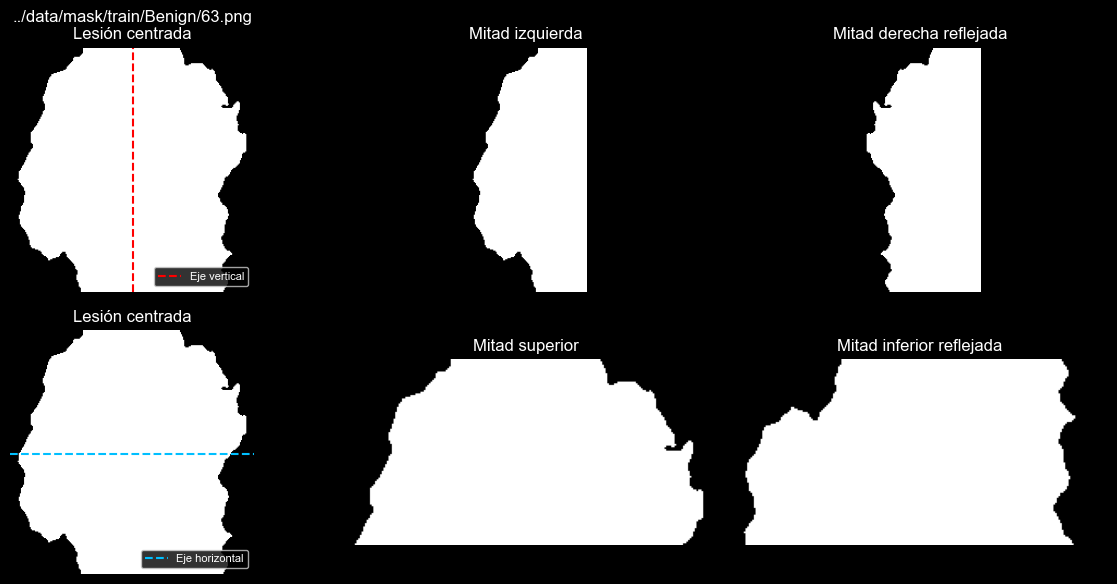

(0.9173814898419864, 0.9226928694728456)

In [27]:
calcular_simetria("../data/mask/train/Benign/63.png",visualizar=True)

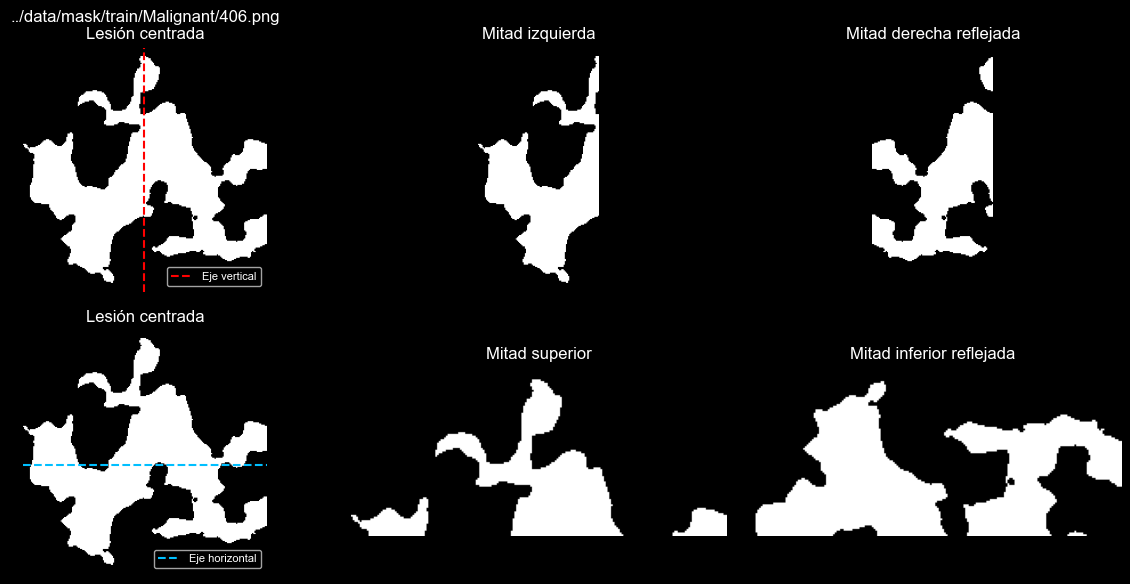

(0.5650109100243872, 0.46553715825953024)

In [31]:
calcular_simetria("../data/mask/train/Malignant/406.png", visualizar=True)


In [27]:
resultados_sim = []

for cls in classes:  
    cls_dir = base_dir / cls
    mask_paths = list(cls_dir.glob("*.png"))

    for path in mask_paths:
        sim_v, sim_h = calcular_simetria(path)
        resultados_sim.append({
            "nombre_imagen": path.name,
            "clase": cls,
            "simetria_vertical": sim_v,
            "simetria_horizontal": sim_h,
            "simetria_media": np.mean([sim_v, sim_h])  
        })


df_simetria = pd.DataFrame(resultados_sim)
df_simetria

,nombre_imagen,clase,simetria_vertical,simetria_horizontal,simetria_media
0,3975.png,Benign,0.868217,0.868217,0.868217
1,348.png,Benign,0.832037,0.819307,0.825672
2,1804.png,Benign,0.793351,0.830752,0.812051
3,4968.png,Benign,0.904613,0.916341,0.910477
4,1810.png,Benign,0.769424,0.788489,0.778957
...,...,...,...,...,...
11874,345.png,Malignant,0.739045,0.720266,0.729656
11875,4971.png,Malignant,0.620139,0.696691,0.658415
11876,4965.png,Malignant,0.879424,0.865623,0.872524
11877,351.png,Malignant,0.640366,0.684128,0.662247


### BoxPlot

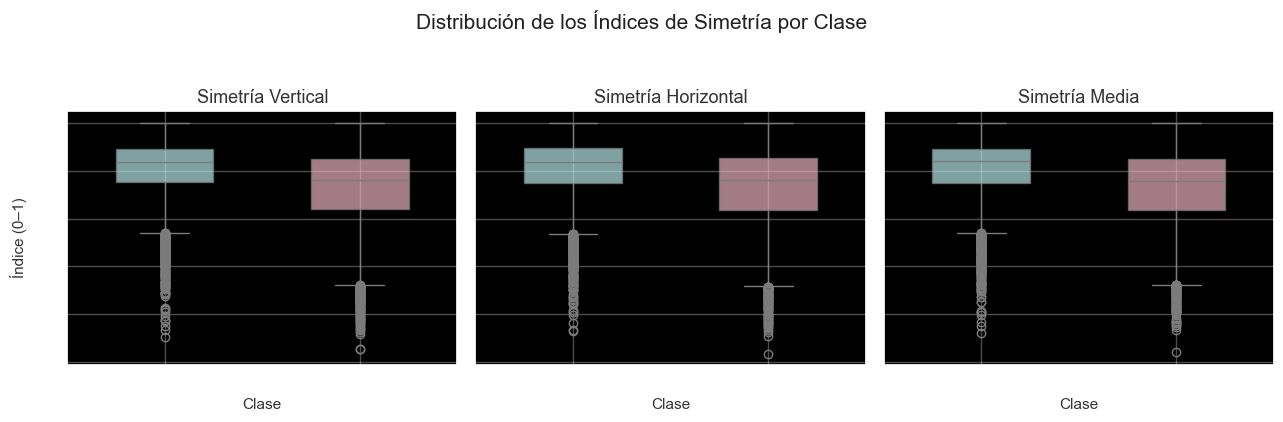

In [28]:
palette_sim = {"Benign": "#AEEEEE", "Malignant": "#F4A7B9"}

# Crear figura
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.patch.set_facecolor("white")

sns.boxplot(
    data=df_simetria,
    x="clase",
    y="simetria_vertical",
    hue="clase",
    dodge=False,
    legend=False,
    palette=palette_sim,
    width=0.5,
    boxprops=dict(alpha=0.7),
    ax=axes[0]
)
axes[0].set_title("Simetría Vertical", fontsize=13, color="#333")
axes[0].set_xlabel("Clase", fontsize=11, color="#333")
axes[0].set_ylabel("Índice (0–1)", fontsize=11, color="#333")
axes[0].grid(alpha=0.3)


sns.boxplot(
    data=df_simetria,
    x="clase",
    y="simetria_horizontal",
    hue="clase",
    dodge=False,
    legend=False,
    palette=palette_sim,
    width=0.5,
    boxprops=dict(alpha=0.7),
    ax=axes[1]
)
axes[1].set_title("Simetría Horizontal", fontsize=13, color="#333")
axes[1].set_xlabel("Clase", fontsize=11, color="#333")
axes[1].set_ylabel("", fontsize=11)
axes[1].grid(alpha=0.3)


sns.boxplot(
    data=df_simetria,
    x="clase",
    y="simetria_media",
    hue="clase",
    dodge=False,
    legend=False,
    palette=palette_sim,
    width=0.5,
    boxprops=dict(alpha=0.7),
    ax=axes[2]
)
axes[2].set_title("Simetría Media", fontsize=13, color="#333")
axes[2].set_xlabel("Clase", fontsize=11, color="#333")
axes[2].set_ylabel("", fontsize=11)
axes[2].grid(alpha=0.3)


plt.suptitle("Distribución de los Índices de Simetría por Clase", fontsize=15, color="#222", y=1.05)
plt.tight_layout()
plt.show()


In [29]:
stats = (
    df_simetria
    .groupby("clase")[["simetria_vertical", "simetria_horizontal", "simetria_media"]]
    .mean()
)

stats

,simetria_vertical,simetria_horizontal,simetria_media
clase,,,
Benign,0.803841,0.805131,0.804486
Malignant,0.729736,0.730287,0.730012


## Función final

In [35]:
def extraer_features(mask_path):
    try:
        area = calcular_area(mask_path)
        perimetro = calcular_perimetro(mask_path)
        circularidad = calcular_circularidad(mask_path)
        sim_v, sim_h = calcular_simetria(mask_path)
    except Exception as e:
        print(f"Error en {mask_path}: {e}")
        area = perimetro = circularidad = sim_v = sim_h = np.nan
    
    return {
        "filename": mask_path.name,
        "area": area,
        "perimetro": perimetro,
        "circularidad": circularidad,
        "simetria_v": sim_v,
        "simetria_h": sim_h
    }

In [ ]:
def generar_dataframe(base_dir):
    data = []
    for cls in classes:
        folder = base_dir / cls
        for mask_path in tqdm(list(folder.glob("*.png")), desc=f"Procesando {cls}"):
            features = extraer_features(mask_path)
            features["label"] = cls
            data.append(features)
    df = pd.DataFrame(data)
    ordered_cols = ["filename", "label", "area", "perimetro", "circularidad", "simetria_v", "simetria_h"]
    df = df[ordered_cols]
    df = df.set_index("filename")
    return df

In [41]:
train_df = generar_dataframe(Path("../data/mask/train"))
test_df = generar_dataframe(Path("../data/mask/test"))


Procesando Malignant: 100%|██████████| 1000/1000 [00:01<00:00, 676.88it/s]


In [53]:
def ordenar_dataframe(df):
    df["num"] = df.index.str.replace(".png", "", regex=False).astype(int)
    df = df.sort_values(by=["label", "num"], ascending=[True, True])
    df = df.drop(columns="num")
    df.index.name = "filename"
    return df

# Aplicar
train_df = ordenar_dataframe(train_df)
test_df = ordenar_dataframe(test_df)

In [55]:
print("Distribución en TRAIN:")
print(train_df["label"].value_counts(), "\n")

print("Distribución en TEST:")
print(test_df["label"].value_counts())


Distribución en TRAIN:
label
Benign       6289
Malignant    5590
Name: count, dtype: int64 

Distribución en TEST:
label
Benign       1000
Malignant    1000
Name: count, dtype: int64


In [60]:
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(reports_dir / "features_train.csv", index=True)
test_df.to_csv(reports_dir / "features_test.csv", index=True)